In [1]:
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import numpy as np
import math
import os, bz2, statistics
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
plt.rcParams['svg.fonttype'] = 'none'
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import fdrcorrection

In [2]:
metadata = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_metadata.tsv', sep='\t')
metadata

,study_name,sample_id,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,...,non_westernized,sequencing_platform,PMID,number_reads,number_bases,minimum_read_length,median_read_length,NCBI_accession,curator,DNA_extraction_kit
0,NielsenHB_2014,O2_UC49_0,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,60584637.0,4.099972e+09,30.0,70.0,ERR210493;ERR210492;ERR209641;ERR209640,Paolo_Manghi,NaN
1,NielsenHB_2014,O2_UC49_2,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,56508214.0,3.775477e+09,30.0,70.0,ERR210495;ERR210494;ERR209643;ERR209642,Paolo_Manghi,NaN
2,NielsenHB_2014,O2_UC50_0,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,65105855.0,4.392995e+09,30.0,71.0,ERR210497;ERR210496;ERR209645;ERR209644,Paolo_Manghi,NaN
3,NielsenHB_2014,O2_UC50_2,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,53260679.0,3.596382e+09,30.0,70.0,ERR210500;ERR209648,Paolo_Manghi,NaN
4,NielsenHB_2014,O2_UC51_0,O2_UC51,stool,NaN,control,healthy,32.0,adult,female,...,no,IlluminaHiSeq,24997787.0,57486896.0,3.923766e+09,30.0,72.0,ERR210502;ERR210501;ERR209650;ERR209649,Paolo_Manghi,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,BorryM_2020,SAMEA6415059,SAMEA6415059,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12866,BorryM_2020,ERR3761407,ERR3761407,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12867,BorryM_2020,ERR3761411,ERR3761411,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12868,HaganRW_2019,Zape5,Zape5,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
abundances = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_profiles.tsv')
abundances.index = abundances['Unnamed: 0']
abundances = abundances.drop('Unnamed: 0',axis=1)
abundances

,MMRS62666492ST-27-0-0,MMRS51737257ST-27-0-0,MMRS38861560ST-27-0-0,MMRS95674036ST-27-0-0,MMRS67096717ST-27-0-0,MMRS84085284ST-27-0-0,MMRS51307502ST-27-0-0,MMRS17963147ST-27-0-0,MMRS39582183ST-27-0-0,MMRS35808664ST-27-0-0,...,SID15785561_SF07,SID19401504_SF05,SID20269046_SF08,SID50492523_SF07,SID10502288_SF08,SID72242320_SF07,SID30920067_SF07,SID11486372_SF08,SID16913125_SF05,SID16853657_SF05
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
k__Bacteria,99.93463,99.18388,100.00000,100.00000,100.00000,100.00000,97.99128,99.92570,93.18519,99.99433,...,100.00000,100.00000,99.20735,100.00000,99.62772,99.57517,99.92819,99.93030,99.53060,100.00000
k__Archaea,0.06537,0.81612,0.00000,0.00000,0.00000,0.00000,2.00872,0.07430,6.81481,0.00567,...,0.00000,0.00000,0.79265,0.00000,0.37228,0.42483,0.07181,0.06970,0.46940,0.00000
k__Bacteria|p__Firmicutes,69.66820,58.11043,69.86201,28.13507,54.76472,48.93404,81.31657,53.89673,70.39620,38.26343,...,62.99205,57.98725,77.37153,56.84940,62.01985,70.64182,57.19654,64.96287,72.69495,56.00511
k__Bacteria|p__Bacteroidetes,28.66924,37.02095,28.10208,66.97080,20.40542,48.32282,10.73218,42.41865,19.37239,51.40790,...,35.22573,38.97574,16.54528,35.27852,27.46251,21.14656,39.11211,20.96019,17.53030,37.48840
k__Bacteria|p__Proteobacteria,0.67858,1.44754,0.66079,2.82776,0.67835,0.02112,3.02764,2.76147,1.31107,9.69329,...,0.49921,0.86482,0.72299,3.39898,3.28930,2.96303,1.12058,11.84127,2.04371,0.62305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidales_unclassified|g__GGB27883|s__GGB27883_SGB40317,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidales_unclassified|g__GGB27883|s__GGB27883_SGB40317|t__SGB40317,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
k__Bacteria|p__Bacteroidetes|c__CFGB570|o__OFGB570|f__FGB570|g__GGB1201,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [4]:
# Only rarefied abundances
abundances = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/rarefied_hg_r.tsv')
abundances.index = abundances['clade_name']
abundances = abundances.drop('clade_name',axis=1)
abundances.columns = [x[:-3] for x in abundances.columns.tolist()]
abundances

,COL_10BH,COL_10MH,COL_11BH,COL_11MH,COL_13BH,COL_13MH,COL_15BH,COL_15MH,COL_16BH,COL_16MH,...,TZ_83788,TZ_83893,TZ_83985,TZ_86768,TZ_86771,TZ_87532,TZ_90808,TZ_91827,TZ_93321,TZ_99300
clade_name,,,,,,,,,,,,,,,,,,,,,
k__Bacteria,100.00000,100.00000,100.00000,99.95992,100.0000,99.96997,100.00000,100.00000,100.00000,100.00000,...,100.00000,99.59166,99.96104,100.00000,98.83012,100.00000,100.00000,97.36303,100.00000,98.31427
k__Bacteria|p__Actinobacteria,92.98434,75.91813,89.47926,5.44682,97.0901,25.47601,77.62444,62.69728,97.47905,2.81394,...,0.43543,1.54283,0.52543,0.16638,2.10308,4.31060,0.16164,2.27485,1.30925,1.49161
k__Bacteria|p__Firmicutes,3.83184,14.73610,7.35664,55.01218,2.3150,59.50758,0.65049,25.21725,0.49695,75.31068,...,22.49169,62.88519,33.98326,40.75336,86.84824,91.40835,28.84553,85.99040,40.71516,70.35111
k__Bacteria|p__Proteobacteria,3.14416,0.26663,3.16410,27.45602,0.5652,8.10115,21.72507,12.07469,2.02399,5.62957,...,1.96696,8.21476,1.62569,5.44908,0.18404,0.44148,3.91644,1.75777,2.20570,1.34752
k__Bacteria|p__Bacteroidetes,0.03966,8.99784,0.00000,5.59185,0.0297,4.46315,0.00000,0.00000,0.00000,13.68916,...,65.86954,21.58429,58.26750,52.23502,6.12562,1.05621,38.73269,2.31837,47.45884,18.81492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Prevotellaceae|g__GGB12950,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2.14815,0.00000,0.00000,0.00000
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Prevotellaceae|g__GGB12950|s__GGB12950_SGB20101,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2.04382,0.00000,0.00000,0.00000
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Prevotellaceae|g__GGB12950|s__GGB12950_SGB20102,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.10434,0.00000,0.00000,0.00000


In [5]:
keep = list()
for x in abundances.index.tolist():
    keep.append('t__' in x)
sgb_abundances = abundances.loc[keep]
sgb_abundances.index = [x.split('|')[-2][3:].replace('_',' ') + ' (' + x.split('|')[-1][3:] +')' for x in sgb_abundances.index.tolist()]
sgb_abundances

,COL_10BH,COL_10MH,COL_11BH,COL_11MH,COL_13BH,COL_13MH,COL_15BH,COL_15MH,COL_16BH,COL_16MH,...,TZ_83788,TZ_83893,TZ_83985,TZ_86768,TZ_86771,TZ_87532,TZ_90808,TZ_91827,TZ_93321,TZ_99300
Bifidobacterium longum (SGB17248),70.97521,0.06069,0.00000,0.00000,97.02233,3.10222,0.17509,22.47583,0.00000,0.00000,...,0.0,0.0000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0
Olsenella uli (SGB14381),21.97844,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.0000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0
Escherichia coli (SGB10068),3.08939,0.01826,3.16410,22.90653,0.56520,1.06179,12.61811,2.09564,1.70536,0.19211,...,0.0,0.0000,0.0,0.0,0.0,0.41267,0.00000,0.0,0.0,0.0
Megasphaera sp BL7 (SGB5858),1.66996,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.79917,0.00000,0.00000,...,0.0,0.0000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0
Ruminococcus gnavus (SGB4584),1.32839,0.00000,0.15499,0.11416,0.14785,0.00000,0.00000,0.08635,0.00000,0.00000,...,0.0,0.0000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Clostridium bornimense (SGB6126),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.0000,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0
Clostridium thermobutyricum (SGB6193),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.0819,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0
Romboutsia hominis (SGB24890),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.0013,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0
GGB12950 SGB20101 (SGB20101),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.0000,0.0,0.0,0.0,0.00000,2.04382,0.0,0.0,0.0


In [6]:
adults_metadata = metadata[metadata['age'] != pd.NA]
adults_metadata = adults_metadata[adults_metadata['age'] != np.nan]
adults_metadata = adults_metadata[adults_metadata['age'].notna()]
adults_metadata = adults_metadata[adults_metadata['age'] != '1.083.333.333']
adults_metadata['age'] = adults_metadata['age'].astype(float)
adults_metadata = adults_metadata[adults_metadata['age'] > 16]
m = pd.DataFrame(metadata)
china = m[m['study_name'] == 'CM_china']
china = china[china['age'].isna()]
adults_metadata = adults_metadata.append(china)
m = pd.DataFrame(metadata)
adults_metadata.index = adults_metadata['sample_id']
adults_metadata

/tmp/ipykernel_385789/1000537149.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  adults_metadata = adults_metadata.append(china)


,study_name,sample_id,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,...,non_westernized,sequencing_platform,PMID,number_reads,number_bases,minimum_read_length,median_read_length,NCBI_accession,curator,DNA_extraction_kit
sample_id,,,,,,,,,,,,,,,,,,,,,
O2_UC49_0,NielsenHB_2014,O2_UC49_0,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,60584637.0,4.099972e+09,30.0,70.0,ERR210493;ERR210492;ERR209641;ERR209640,Paolo_Manghi,NaN
O2_UC49_2,NielsenHB_2014,O2_UC49_2,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,56508214.0,3.775477e+09,30.0,70.0,ERR210495;ERR210494;ERR209643;ERR209642,Paolo_Manghi,NaN
O2_UC50_0,NielsenHB_2014,O2_UC50_0,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,65105855.0,4.392995e+09,30.0,71.0,ERR210497;ERR210496;ERR209645;ERR209644,Paolo_Manghi,NaN
O2_UC50_2,NielsenHB_2014,O2_UC50_2,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,53260679.0,3.596382e+09,30.0,70.0,ERR210500;ERR209648,Paolo_Manghi,NaN
O2_UC51_0,NielsenHB_2014,O2_UC51_0,O2_UC51,stool,NaN,control,healthy,32.0,adult,female,...,no,IlluminaHiSeq,24997787.0,57486896.0,3.923766e+09,30.0,72.0,ERR210502;ERR210501;ERR209650;ERR209649,Paolo_Manghi,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHN_26G3,CM_china,CHN_26G3,CHN_26G3,stool,NaN,control,healthy,NaN,NaN,female,...,yes,IlluminaNovaSeq,1.0,452852232.0,6.797313e+10,75.0,151.0,NaN,Mireia_Valles-Colomer,NaN
CHN_2D3,CM_china,CHN_2D3,CHN_2D3,stool,NaN,control,healthy,NaN,NaN,female,...,yes,IlluminaNovaSeq,1.0,82005669.0,1.227308e+10,75.0,151.0,NaN,Mireia_Valles-Colomer,NaN
CHN_4E3,CM_china,CHN_4E3,CHN_4E3,stool,NaN,control,healthy,NaN,NaN,female,...,yes,IlluminaNovaSeq,1.0,40651703.0,6.096303e+09,75.0,151.0,NaN,Mireia_Valles-Colomer,NaN


In [7]:
adults_abundances = sgb_abundances[[x for x in adults_metadata['sample_id'] if x in sgb_abundances.columns.tolist()]]
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())
adults_abundances = adults_abundances.transpose()
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())
adults_abundances

,Bifidobacterium longum (SGB17248),Olsenella uli (SGB14381),Escherichia coli (SGB10068),Megasphaera sp BL7 (SGB5858),Ruminococcus gnavus (SGB4584),Streptococcus sp IMAU 99161 (SGB8065),Enterococcus faecium (SGB7967),Enterococcus raffinosus (SGB7930),Klebsiella pneumoniae (SGB10115),Phocaeicola vulgatus (SGB1814),...,Eggerthellaceae bacterium (SGB14339),Bacteroidales bacterium (SGB2092),Desulfovibrionaceae bacterium (SGB57322),Clostridia unclassified SGB13967 (SGB13967),Fibrobacter intestinalis (SGB3193),Ruminococcaceae bacterium (SGB47497),GGB13846 SGB21231 (SGB21231),Clostridium bornimense (SGB6126),GGB12950 SGB20101 (SGB20101),GGB12950 SGB20102 (SGB20102)
HCO11,0.00000,0.0,9.37007,0.0000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HCO12,0.00000,0.0,0.00000,0.0000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HCO53,0.00000,0.0,0.02730,0.0000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HCO61,0.00000,0.0,0.00000,0.0000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HCO67,0.00000,0.0,0.00000,0.0000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C16-20627-TZ,0.41102,0.0,0.21977,0.0000,0.11429,0.0,0.00000,0.0,0.00000,7.70724,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20645-TZ,0.00000,0.0,0.00000,0.0000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20646-TZ,0.00000,0.0,0.12073,0.0000,0.00000,0.0,0.00000,0.0,0.00000,0.02763,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20647-TZ,0.00000,0.0,0.03982,0.0000,0.00000,0.0,0.00000,0.0,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
adults_abundances = adults_abundances.astype(bool).astype(int)

## Get PER samples metadata

In [9]:
per_samples = adults_metadata[adults_metadata['study_name'].isin(['CM_colombia', 'Obregon-TitoAJ_2015'])]
per_samples = per_samples[per_samples['country'].isin(['COL','PER'])]
per_rural = [x for x in per_samples.index.tolist() if x.startswith('HC') or x.startswith('COL')]
per_hg = [x for x in per_samples.index.tolist() if x.startswith('SM')]
per_rural = per_samples.loc[per_rural,]
per_hg = per_samples.loc[per_hg,]

## Get CMR samples metadata

In [10]:
rubel = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/tools/curatedMetagenomicDataCuration/inst/curated/RubelMA_2020/RubelMA_2020_metadata.tsv', sep='\t')
rubel.index = rubel['sample_id']
rubel_hg = rubel[rubel['lifestyle'] == 'Hunter-gatherer'].index.tolist()
rubel_r = rubel[rubel['lifestyle'] != 'Hunter-gatherer'].index.tolist()

In [11]:
cmr_samples = adults_metadata[adults_metadata['study_name'].isin(['RubelMA_2020', 'LokmerA_2019'])]
cmr_samples = cmr_samples[cmr_samples['country'] == 'CMR']
cmr_samples
rubel = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/tools/curatedMetagenomicDataCuration/inst/curated/RubelMA_2020/RubelMA_2020_metadata.tsv', sep='\t')
lokmer_hg = cmr_samples[cmr_samples['subject_id'].str.startswith('BAB')].index.tolist()
cmr_hg = lokmer_hg 
cmr_hg += [x for x in cmr_samples[cmr_samples['study_name'] == 'RubelMA_2020'].index.tolist() if x in rubel_hg]
cmr_rural = [x for x in cmr_samples[cmr_samples['study_name'] == 'LokmerA_2019'].index.tolist() if x not in lokmer_hg]
cmr_rural += [x for x in cmr_samples[cmr_samples['study_name'] == 'RubelMA_2020'].index.tolist() if x in rubel_r]
cmr_rural = cmr_samples.loc[cmr_rural,]
cmr_hg = cmr_samples.loc[cmr_hg,]

## Get TZA samples metadata

In [12]:
tza_samples = adults_metadata[adults_metadata['study_name'].isin(['SmitsSA_2017', 'RampelliS_2015', 'CM_tanzania', 'CM_tanzania2'])]
tza_samples = tza_samples[tza_samples['country'] == 'TZA']
tza_hg = tza_samples[tza_samples['study_name'].isin(['SmitsSA_2017', 'RampelliS_2015'])].index.tolist()
tza_rural = tza_samples[tza_samples['study_name'].isin(['CM_tanzania', 'CM_tanzania2'])].index.tolist()
tza_rural = tza_samples.loc[tza_rural,]
tza_hg = tza_samples.loc[tza_hg,]
taz_dar = adults_metadata[adults_metadata['study_name'].isin(['CM_tanzania_TB_DAR'])]

In [13]:
taz_dar

,study_name,sample_id,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,...,non_westernized,sequencing_platform,PMID,number_reads,number_bases,minimum_read_length,median_read_length,NCBI_accession,curator,DNA_extraction_kit
sample_id,,,,,,,,,,,,,,,,,,,,,
83141_31,CM_tanzania_TB_DAR,83141_31,83141,stool,NaN,control,healthy,78.0,senior,female,...,yes,IlluminaNovaSeq,NaN,83676628.0,1.257751e+10,75.0,151.0,NaN,NaN,NaN
83149_31,CM_tanzania_TB_DAR,83149_31,83149,stool,NaN,control,healthy,53.0,adult,female,...,yes,IlluminaNovaSeq,NaN,45360337.0,6.817095e+09,75.0,151.0,NaN,NaN,NaN
83167_31,CM_tanzania_TB_DAR,83167_31,83167,stool,NaN,control,healthy,41.0,adult,male,...,yes,IlluminaNovaSeq,NaN,39194051.0,5.890732e+09,75.0,151.0,NaN,NaN,NaN
83237_31,CM_tanzania_TB_DAR,83237_31,83237,stool,NaN,control,healthy,39.0,adult,male,...,yes,IlluminaNovaSeq,NaN,110305179.0,1.656563e+10,75.0,151.0,NaN,NaN,NaN
83274_31,CM_tanzania_TB_DAR,83274_31,83274,stool,NaN,control,healthy,32.0,adult,male,...,yes,IlluminaNovaSeq,NaN,79415129.0,1.193302e+10,75.0,151.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83997_31,CM_tanzania_TB_DAR,83997_31,83997,stool,NaN,control,healthy,37.0,adult,male,...,yes,IlluminaNovaSeq,NaN,36309741.0,5.457150e+09,75.0,151.0,NaN,NaN,NaN
84000_31,CM_tanzania_TB_DAR,84000_31,84000,stool,NaN,control,healthy,48.0,adult,male,...,yes,IlluminaNovaSeq,NaN,88833589.0,1.334083e+10,75.0,151.0,NaN,NaN,NaN
84001_31,CM_tanzania_TB_DAR,84001_31,84001,stool,NaN,control,healthy,35.0,adult,male,...,yes,IlluminaNovaSeq,NaN,40384562.0,6.070968e+09,75.0,151.0,NaN,NaN,NaN


##  Number of samples

In [14]:
print('CMR H-G:', len(cmr_hg))
print('CMR rural:', len(cmr_rural))

print('PER H-G:', len(per_hg))
print('PER rural:', len(per_rural))

print('TZA H-G:', len(tza_hg))
print('TZA rural:', len(tza_rural))
print('TZA urban:', len(taz_dar))

CMR H-G: 21
CMR rural: 118
PER H-G: 10
PER rural: 17
TZA H-G: 39
TZA rural: 98
TZA urban: 217


## Preliminary analyses

In [51]:
tza_abundances = adults_abundances.loc[[x for x in tza_hg.index.tolist() + tza_rural.index.tolist() + taz_dar.index.tolist() if x in adults_abundances.index.tolist()],]
tza_abundances = tza_abundances.drop(tza_abundances.loc[tza_abundances.sum(axis=1) == 0].index.tolist())
tza_abundances = tza_abundances.transpose()
tza_abundances = tza_abundances.drop(tza_abundances.loc[tza_abundances.sum(axis=1) == 0].index.tolist())
tza_abundances = tza_abundances.transpose()
cmr_abundances = adults_abundances.loc[[x for x in cmr_hg.index.tolist() + cmr_rural.index.tolist() if x in adults_abundances.index.tolist()],]
cmr_abundances = cmr_abundances.drop(cmr_abundances.loc[cmr_abundances.sum(axis=1) == 0].index.tolist())
cmr_abundances = cmr_abundances.transpose()
cmr_abundances = cmr_abundances.drop(cmr_abundances.loc[cmr_abundances.sum(axis=1) == 0].index.tolist())
cmr_abundances = cmr_abundances.transpose()
per_abundances = adults_abundances.loc[[x for x in per_hg.index.tolist() + per_rural.index.tolist() if x in adults_abundances.index.tolist()],]
per_abundances = per_abundances.drop(per_abundances.loc[per_abundances.sum(axis=1) == 0].index.tolist())
per_abundances = per_abundances.transpose()
per_abundances = per_abundances.drop(per_abundances.loc[per_abundances.sum(axis=1) == 0].index.tolist())
per_abundances = per_abundances.transpose()

### Alpha diversity

In [52]:
cmr_hg_df = pd.DataFrame(cmr_abundances.loc[cmr_hg.index.tolist()].transpose().sum())
cmr_hg_df.columns = ['SGBs']
cmr_hg_df['group'] = 'CMR_HG'
cmr_hg_df['country'] = 'CMR'
cmr_hg_df['population'] = 'Hunter-Gatherer'
cmr_rural_df = pd.DataFrame(cmr_abundances.loc[cmr_rural.index.tolist()].transpose().sum())
cmr_rural_df.columns = ['SGBs']
cmr_rural_df['group'] = 'CMR_R'
cmr_rural_df['country'] = 'CMR'
cmr_rural_df['population'] = 'Rural'

per_hg_df = pd.DataFrame(per_abundances.loc[per_hg.index.tolist()].transpose().sum())
per_hg_df.columns = ['SGBs']
per_hg_df['group'] = 'PER_HG'
per_hg_df['country'] = 'PER'
per_hg_df['population'] = 'Hunter-Gatherer'
per_rural_df = pd.DataFrame(per_abundances.loc[per_rural.index.tolist()].transpose().sum())
per_rural_df.columns = ['SGBs']
per_rural_df['group'] = 'PER_R'
per_rural_df['country'] = 'PER'
per_rural_df['population'] = 'Rural'

tza_hg_df = pd.DataFrame(tza_abundances.loc[tza_hg.index.tolist()].transpose().sum())
tza_hg_df.columns = ['SGBs']
tza_hg_df['group'] = 'TZA_HG'
tza_hg_df['country'] = 'TZA'
tza_hg_df['population'] = 'Hunter-Gatherer'
tza_rural_df = pd.DataFrame(tza_abundances.loc[[x for x in tza_rural.index.tolist() if x in tza_abundances.index.tolist()]].transpose().sum())
tza_rural_df.columns = ['SGBs']
tza_rural_df['group'] = 'TZA_R'
tza_rural_df['country'] = 'TZA'
tza_rural_df['population'] = 'Rural'
tza_tbdar_df = pd.DataFrame(tza_abundances.loc[[x for x in taz_dar.index.tolist() if x in tza_abundances.index.tolist()]].transpose().sum())
tza_tbdar_df.columns = ['SGBs']
tza_rural_df['group'] = 'TZA_T'
tza_tbdar_df['country'] = 'TZA'
tza_tbdar_df['population'] = 'Urban'

In [96]:
comp_df = cmr_hg_df.append(cmr_rural_df).append(per_hg_df).append(per_rural_df).append(tza_hg_df).append(tza_rural_df)

/tmp/ipykernel_385789/3471450695.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  comp_df = cmr_hg_df.append(cmr_rural_df).append(per_hg_df).append(per_rural_df).append(tza_hg_df).append(tza_rural_df)
/tmp/ipykernel_385789/3471450695.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  comp_df = cmr_hg_df.append(cmr_rural_df).append(per_hg_df).append(per_rural_df).append(tza_hg_df).append(tza_rural_df)
/tmp/ipykernel_385789/3471450695.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  comp_df = cmr_hg_df.append(cmr_rural_df).append(per_hg_df).append(per_rural_df).append(tza_hg_df).append(tza_rural_df)
/tmp/ipykernel_385789/3471450695.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pand

In [95]:
comp_df.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/hgruralurban_metadata.tsv', sep='\t')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PER_Hunter-Gatherer vs. PER_Rural: Mann-Whitney-Wilcoxon test two-sided, P_val:1.596e-01 U_stat=5.650e+01
CMR_Hunter-Gatherer vs. CMR_Rural: Mann-Whitney-Wilcoxon test two-sided, P_val:2.008e-01 U_stat=1.457e+03
TZA_Hunter-Gatherer vs. TZA_Rural: Mann-Whitney-Wilcoxon test two-sided, P_val:6.567e-11 U_stat=3.249e+03


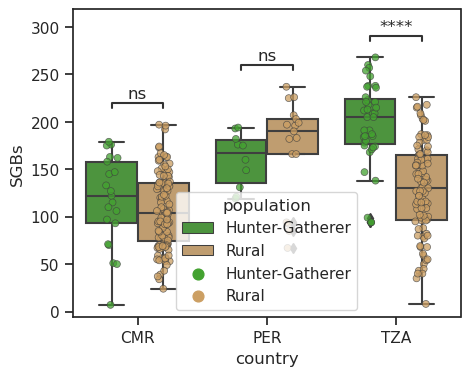

In [54]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.figsize'] = [5,4]

pairs = [
    [('CMR', 'Hunter-Gatherer'), ('CMR', 'Rural')],
    [('PER', 'Hunter-Gatherer'), ('PER', 'Rural')],
    [('TZA', 'Hunter-Gatherer'), ('TZA', 'Rural')]
]

hue_plot_params = {
    'data': comp_df,
    'x': 'country',
    'y': 'SGBs',
    "hue": "population"
}

ax = sns.boxplot(data=comp_df, y='SGBs', hue='population', x='country', palette=['#43a230','#cc9f63'])
annotator = Annotator(ax, pairs, **hue_plot_params)
annotator.configure(test="Mann-Whitney").apply_and_annotate()
sns.stripplot(data=comp_df, y='SGBs', hue='population', x='country', dodge=True, linewidth=0.5, alpha=0.75, palette=['#43a230','#cc9f63'])
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/alpha_hg_rural.svg')

In [94]:
comp_df = tza_hg_df.append(tza_rural_df).append(tza_tbdar_df)

/tmp/ipykernel_385789/2417451534.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  comp_df = tza_hg_df.append(tza_rural_df).append(tza_tbdar_df)
/tmp/ipykernel_385789/2417451534.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  comp_df = tza_hg_df.append(tza_rural_df).append(tza_tbdar_df)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Hunter-Gatherer vs. Rural: Mann-Whitney-Wilcoxon test two-sided, P_val:6.567e-11 U_stat=3.249e+03
Rural vs. Urban: Mann-Whitney-Wilcoxon test two-sided, P_val:7.382e-12 U_stat=1.562e+04
Hunter-Gatherer vs. Urban: Mann-Whitney-Wilcoxon test two-sided, P_val:2.114e-20 U_stat=8.172e+03


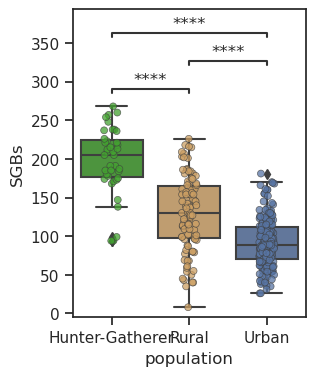

In [56]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.figsize'] = [3,4]

pairs = [
    ['Hunter-Gatherer', 'Rural'],
    ['Hunter-Gatherer', 'Urban'],
    ['Rural', 'Urban']
]

hue_plot_params = {
    'data': comp_df,
    'x': 'population',
    'y': 'SGBs'
}

ax = sns.boxplot(data=comp_df, y='SGBs', x='population', palette=['#43a230','#cc9f63', '#5875a4'])
annotator = Annotator(ax, pairs, **hue_plot_params)
annotator.configure(test="Mann-Whitney").apply_and_annotate()

sns.stripplot(data=comp_df, y='SGBs', x='population', dodge=True, linewidth=0.5, alpha=0.75, palette=['#43a230','#cc9f63', '#5875a4'])
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/alpha_tza.svg')

In [57]:
print(tza_hg['number_reads'].min())
print(tza_rural['number_reads'].min())
print(taz_dar['number_reads'].min())
print(per_hg['number_reads'].min())
print(per_rural['number_reads'].min())
print(cmr_hg['number_reads'].min())
print(cmr_rural['number_reads'].min())

2111411.0
18129274.0
3012336.0
56122220.0
8800389.0
9535850.0
9414992.0


### Beta diversity

In [35]:
def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.

    Parameters
    ----------
    x, y : array-like, shape (n, )
        Input data.

    ax : matplotlib.axes.Axes
        The axes object to draw the ellipse into.

    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.

    **kwargs
        Forwarded to `~matplotlib.patches.Ellipse`

    Returns
    -------
    matplotlib.patches.Ellipse
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)

    # Calculating the standard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)

    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

In [58]:
all_prevalences

,Bifidobacterium longum (SGB17248),Olsenella uli (SGB14381),Escherichia coli (SGB10068),Megasphaera sp BL7 (SGB5858),Ruminococcus gnavus (SGB4584),Streptococcus sp IMAU 99161 (SGB8065),Enterococcus faecium (SGB7967),Klebsiella pneumoniae (SGB10115),Phocaeicola vulgatus (SGB1814),Bifidobacterium breve (SGB17247),...,Eggerthellaceae bacterium (SGB14339),Bacteroidales bacterium (SGB2092),Desulfovibrionaceae bacterium (SGB57322),Clostridia unclassified SGB13967 (SGB13967),Fibrobacter intestinalis (SGB3193),Ruminococcaceae bacterium (SGB47497),GGB13846 SGB21231 (SGB21231),Clostridium bornimense (SGB6126),GGB12950 SGB20101 (SGB20101),GGB12950 SGB20102 (SGB20102)
TZ_81781,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TZ_42864,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TZ_76219,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TZ_70090,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TZ_24827,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
COL_16MH,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
COL_2MH,0,0,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
COL_4MH,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
COL_5MH,1,0,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [73]:
all_prevalences = adults_abundances.loc[[x for x in tza_hg.index.tolist() + tza_rural.index.tolist() + cmr_hg.index.tolist() + cmr_rural.index.tolist() + per_hg.index.tolist() + per_rural.index.tolist() if x in adults_abundances.index.tolist()],]
all_prevalences = all_prevalences.drop(all_prevalences.loc[all_prevalences.sum(axis=1) == 0].index.tolist())
all_prevalences = all_prevalences.transpose()
all_prevalences = all_prevalences.drop(all_prevalences.loc[all_prevalences.sum(axis=1) == 0].index.tolist())
all_prevalences = all_prevalences.transpose()
jaccard_r_hg = beta_diversity(metric="jaccard", counts=all_prevalences.values, ids=all_prevalences.index)
jcc_pcoa = pcoa(jaccard_r_hg)

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:143: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.01682363325845228 and the largest is 9.142290233254146.
  warn(


In [74]:
colors = list()
colors2 = list()
size = list()
styles = list()

for x in tza_hg.index.tolist():
    styles.append('x')
    size.append(80)
    colors.append('#43a230')
    colors2.append('#2364DC')
    
for x in tza_rural.index.tolist():
    if x in tza_abundances.index.tolist():
        styles.append('x')
        size.append(80)
        colors.append('#cc9f63')
        colors2.append('#DC9B23')
        
for x in cmr_hg.index.tolist():
    styles.append('+')
    size.append(80)
    colors.append('#43a230')
    colors2.append('#2364DC')
    
for x in cmr_rural.index.tolist():
    styles.append('+')
    size.append(80)
    colors.append('#cc9f63')
    colors2.append('#DC9B23')
    
for x in per_hg.index.tolist():
    styles.append('o')
    size.append(80)
    colors.append('#43a230')
    colors2.append('#2364DC')
        
for x in per_rural.index.tolist():
    styles.append('o')
    size.append(80)
    if not x.startswith('COL'):
        colors.append('#cc9f63')
    else:
        colors.append('#cc9f63')
    colors2.append('#DC9B23')
        

In [97]:
import skbio
p = skbio.stats.distance.permanova(jaccard_r_hg, colors, permutations=999)

In [98]:
r2 = 1 - 1 / (1 + p[4] * p[3] / (p[2] - p[3] - 1))
r2

0.05855598671337037

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


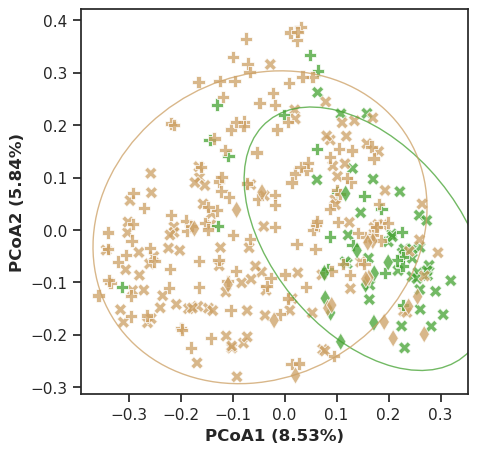

In [76]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
ax = sns.scatterplot(jcc_pcoa.samples['PC1'], jcc_pcoa.samples['PC2'], alpha=0.75, s=size, c=colors,  markers=['X','P','d'], style=styles, legend=False)
var1 = round(100 * jcc_pcoa.eigvals['PC1'] / jcc_pcoa.eigvals.sum() ,2)
var2 = round(100 * jcc_pcoa.eigvals['PC2'] / jcc_pcoa.eigvals.sum() ,2)
plt.xlabel("PCoA1 ({}%)".format(var1), fontdict={'weight': 'bold'})
plt.ylabel("PCoA2 ({}%)".format(var2), fontdict={'weight': 'bold'})
for label in ['#43a230', '#cc9f63']:
    label_list = []
    for i in range(0, len(colors)):
        if colors[i] == label:
            label_list.append(all_prevalences.index[i])
    p1 = [jcc_pcoa.samples['PC1'][x] for x in label_list]
    p2 = [jcc_pcoa.samples['PC2'][x] for x in label_list]
    confidence_ellipse(np.array(p1),np.array(p2), ax, edgecolor=label, alpha=0.75)
plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/beta_hg_rural.svg')

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


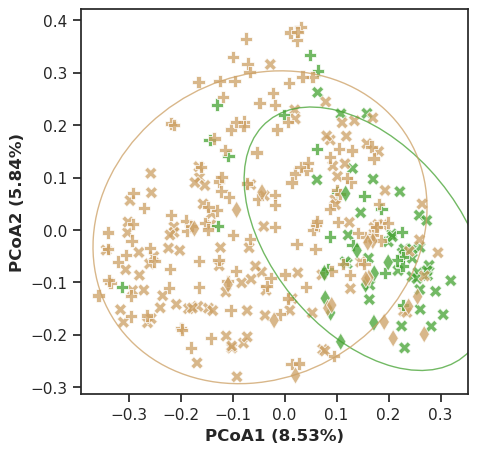

In [63]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
ax = sns.scatterplot(jcc_pcoa.samples['PC1'], jcc_pcoa.samples['PC2'], alpha=0.75, s=size, c=colors,  markers=['X','P','d'], style=styles, legend=False)
var1 = round(100 * jcc_pcoa.eigvals['PC1'] / jcc_pcoa.eigvals.sum() ,2)
var2 = round(100 * jcc_pcoa.eigvals['PC2'] / jcc_pcoa.eigvals.sum() ,2)
plt.xlabel("PCoA1 ({}%)".format(var1), fontdict={'weight': 'bold'})
plt.ylabel("PCoA2 ({}%)".format(var2), fontdict={'weight': 'bold'})
for label in ['#43a230', '#cc9f63']:
    label_list = []
    for i in range(0, len(colors)):
        if colors[i] == label:
            label_list.append(all_prevalences.index[i])
    p1 = [jcc_pcoa.samples['PC1'][x] for x in label_list]
    p2 = [jcc_pcoa.samples['PC2'][x] for x in label_list]
    confidence_ellipse(np.array(p1),np.array(p2), ax, edgecolor=label, alpha=0.75)
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/beta_hg_rural.svg')

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0, 0.5, 'PCoA2')

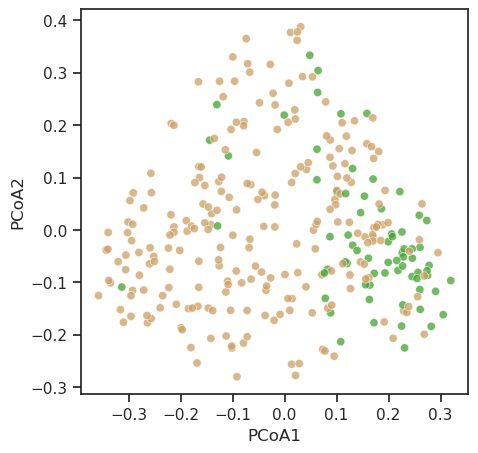

In [65]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
sns.scatterplot(jcc_pcoa.samples['PC1'], jcc_pcoa.samples['PC2'], alpha=0.75,  c=colors, legend=False)
plt.xlabel("PCoA1")
plt.ylabel("PCoA2")

In [64]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
sns.scatterplot(jcc_pcoa.samples['PC1'], jcc_pcoa.samples['PC2'], alpha=0.75, s=size, c=colors2,  markers=['*','o'], style=styles, legend=False)
plt.xlabel("PCoA1")
plt.ylabel("PCoA2")

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


ValueError: The `markers` argument has the wrong number of values

### Tanzania

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:143: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.0027989095675812043 and the largest is 5.380620072714523.
  warn(
/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0, 0.5, 'PCoA2')

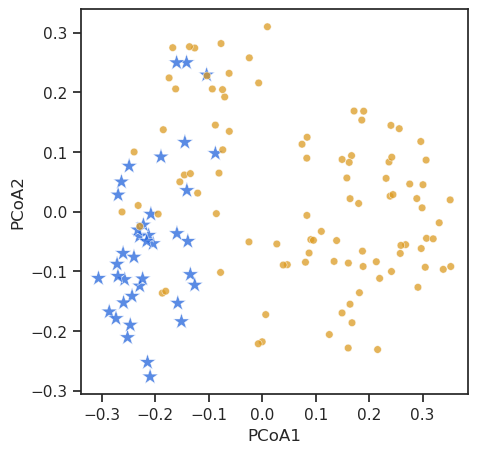

In [66]:
all_prevalences = adults_abundances.loc[[x for x in tza_hg.index.tolist() + tza_rural.index.tolist() if x in adults_abundances.index.tolist()],]
all_prevalences = all_prevalences.drop(all_prevalences.loc[all_prevalences.sum(axis=1) == 0].index.tolist())
all_prevalences = all_prevalences.transpose()
all_prevalences = all_prevalences.drop(all_prevalences.loc[all_prevalences.sum(axis=1) == 0].index.tolist())
all_prevalences = all_prevalences.transpose()
jaccard_r_hg = beta_diversity(metric="jaccard", counts=all_prevalences.values, ids=all_prevalences.index)
jcc_pcoa = pcoa(jaccard_r_hg)
colors = list()
colors2 = list()
size = list()
styles = list()

for x in tza_hg.index.tolist():
    styles.append('*')
    size.append(150)
    colors.append('#C9364F')
    colors2.append('#2364DC')
    
for x in tza_rural.index.tolist():
    if x in tza_abundances.index.tolist():
        styles.append('o')
        size.append(30)
        colors.append('#C9364F')
        colors2.append('#DC9B23') 

sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
sns.scatterplot(jcc_pcoa.samples['PC1'], jcc_pcoa.samples['PC2'], alpha=0.75, s=size, c=colors2,  markers=['*','o'], style=styles, legend=False)
plt.xlabel("PCoA1")
plt.ylabel("PCoA2")

### Peru

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0, 0.5, 'PCoA2')

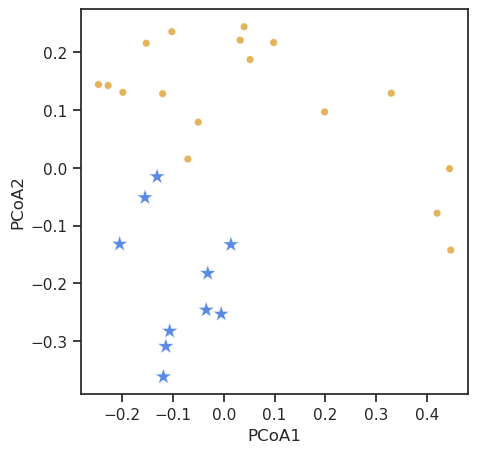

In [67]:
all_prevalences = adults_abundances.loc[[x for x in per_hg.index.tolist() + per_rural.index.tolist() if x in adults_abundances.index.tolist()],]
all_prevalences = all_prevalences.drop(all_prevalences.loc[all_prevalences.sum(axis=1) == 0].index.tolist())
all_prevalences = all_prevalences.transpose()
all_prevalences = all_prevalences.drop(all_prevalences.loc[all_prevalences.sum(axis=1) == 0].index.tolist())
all_prevalences = all_prevalences.transpose()
jaccard_r_hg = beta_diversity(metric="jaccard", counts=all_prevalences.values, ids=all_prevalences.index)
jcc_pcoa = pcoa(jaccard_r_hg)
colors = list()
colors2 = list()
size = list()
styles = list()

for x in per_hg.index.tolist():
    styles.append('*')
    size.append(150)
    colors.append('#C9364F')
    colors2.append('#2364DC')
    
for x in per_rural.index.tolist():
    styles.append('o')
    size.append(30)
    colors.append('#C9364F')
    colors2.append('#DC9B23') 

sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
sns.scatterplot(jcc_pcoa.samples['PC1'], jcc_pcoa.samples['PC2'], alpha=0.75, s=size, c=colors2,  markers=['*','o'], style=styles, legend=False)
plt.xlabel("PCoA1")
plt.ylabel("PCoA2")

### Cameroon

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0, 0.5, 'PCoA2')

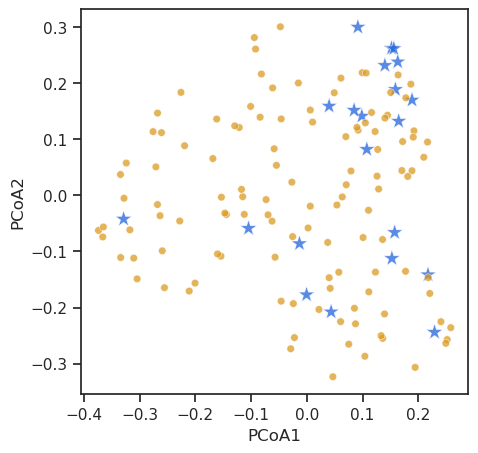

In [68]:
all_prevalences = adults_abundances.loc[[x for x in cmr_hg.index.tolist() + cmr_rural.index.tolist() if x in adults_abundances.index.tolist()],]
all_prevalences = all_prevalences.drop(all_prevalences.loc[all_prevalences.sum(axis=1) == 0].index.tolist())
all_prevalences = all_prevalences.transpose()
all_prevalences = all_prevalences.drop(all_prevalences.loc[all_prevalences.sum(axis=1) == 0].index.tolist())
all_prevalences = all_prevalences.transpose()
jaccard_r_hg = beta_diversity(metric="jaccard", counts=all_prevalences.values, ids=all_prevalences.index)
jcc_pcoa = pcoa(jaccard_r_hg)
colors = list()
colors2 = list()
size = list()
styles = list()

for x in cmr_hg.index.tolist():
    styles.append('*')
    size.append(150)
    colors.append('#C9364F')
    colors2.append('#2364DC')
    
for x in cmr_rural.index.tolist():
    styles.append('o')
    size.append(30)
    colors.append('#C9364F')
    colors2.append('#DC9B23') 

sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
sns.scatterplot(jcc_pcoa.samples['PC1'], jcc_pcoa.samples['PC2'], alpha=0.75, s=size, c=colors2,  markers=['*','o'], style=styles, legend=False)
plt.xlabel("PCoA1")
plt.ylabel("PCoA2")

## Meta-analysis

In [385]:
def arcsinsqrt(x):
    return np.arcsin(math.sqrt((x) / 100))

In [79]:
sgb2species = {x.split('|')[-1]:x.split('|')[-2] for x in abundances.index.tolist() if 't__' in x}

In [352]:
keep = list()
for x in abundances.index.tolist():
    keep.append('t__' in x)
sgb_abundances = abundances.loc[keep]
sgb_abundances.index = [x.split('|')[-1] for x in sgb_abundances.index.tolist()]
adults_abundances = sgb_abundances[adults_metadata['sample_id']]
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())
adults_abundances = adults_abundances.transpose()
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())
adults_abundances

,t__SGB1626,t__SGB4290,t__SGB5117,t__SGB4260,t__SGB15234,t__SGB1814,t__SGB2318,t__SGB5825_group,t__SGB15332_group,t__SGB6571,...,t__SGB32233,t__SGB64172,t__SGB10725,t__SGB32666,t__SGB10726,t__SGB28493,t__SGB89540,t__SGB8530,t__SGB87720,t__SGB11414
O2_UC49_0,0.00000,0.00000,0.00000,0.0000,0.00000,8.56330,2.20573,7.75207,0.06884,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC49_2,0.00000,0.00000,0.00000,0.0000,0.48968,5.54331,1.54382,0.94596,0.26171,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_0,0.99226,7.81511,0.05737,0.0000,0.14505,4.18524,1.23991,0.00000,0.63255,0.00955,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_2,0.00000,5.32192,0.00000,0.0000,0.00000,5.48845,2.04727,0.00000,1.13673,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC51_0,0.00000,0.00000,4.03200,0.7276,0.04497,0.01972,2.71483,0.00180,0.09800,0.04088,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHN_26G3,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CHN_2D3,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CHN_4E3,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CHN_7E3,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [386]:
all_ab = adults_abundances.loc[[x for x in tza_hg.index.tolist() + tza_rural.index.tolist() + cmr_hg.index.tolist() + cmr_rural.index.tolist() + per_hg.index.tolist() + per_rural.index.tolist() if x in adults_abundances.index.tolist()],]
all_ab = all_ab.drop(all_ab.loc[all_ab.sum(axis=1) == 0].index.tolist())
all_ab = all_ab.transpose()
all_ab = all_ab.drop(all_ab.loc[all_ab.sum(axis=1) == 0].index.tolist())
all_ab = all_ab.applymap(arcsinsqrt)

In [387]:
aux_metadata = metadata.copy()
aux_metadata.index = metadata['sample_id']
aux_metadata = aux_metadata.loc[all_ab.columns].transpose()
aux_metadata = aux_metadata.loc[['gender', 'age', 'number_reads']]
aux_metadata = aux_metadata.transpose()

aux_metadata.loc[[x for x in tza_hg.index.tolist() if x in all_ab.columns.tolist()],'lifestyle'] = 'Hunter-gatherer'
aux_metadata.loc[[x for x in tza_hg.index.tolist() if x in all_ab.columns.tolist()],'country'] = 'TZA'
aux_metadata.loc[[x for x in tza_rural.index.tolist() if x in all_ab.columns.tolist()],'lifestyle'] = 'Rural'
aux_metadata.loc[[x for x in tza_rural.index.tolist() if x in all_ab.columns.tolist()],'country'] = 'TZA'

aux_metadata.loc[[x for x in cmr_hg.index.tolist() if x in all_ab.columns.tolist()],'lifestyle'] = 'Hunter-gatherer'
aux_metadata.loc[[x for x in cmr_hg.index.tolist() if x in all_ab.columns.tolist()],'country'] = 'CMR'
aux_metadata.loc[[x for x in cmr_rural.index.tolist() if x in all_ab.columns.tolist()],'lifestyle'] = 'Rural'
aux_metadata.loc[[x for x in cmr_rural.index.tolist() if x in all_ab.columns.tolist()],'country'] = 'CMR'

aux_metadata.loc[[x for x in per_hg.index.tolist() if x in all_ab.columns.tolist()],'lifestyle'] = 'Hunter-gatherer'
aux_metadata.loc[[x for x in per_hg.index.tolist() if x in all_ab.columns.tolist()],'country'] = 'PER'
aux_metadata.loc[[x for x in per_rural.index.tolist() if x in all_ab.columns.tolist()],'lifestyle'] = 'Rural'
aux_metadata.loc[[x for x in per_rural.index.tolist() if x in all_ab.columns.tolist()],'country'] = 'PER'

aux_metadata = aux_metadata.transpose()
aux_metadata

,TZ_81781,TZ_42864,TZ_76219,TZ_70090,TZ_24827,TZ_12739,TZ_39371,TZ_83627,TZ_60579,TZ_86771,...,COL_1MH,COL_10MH,COL_11MH,COL_13MH,COL_15MH,COL_16MH,COL_2MH,COL_4MH,COL_5MH,COL_6MH
gender,female,male,male,female,female,female,male,female,male,male,...,female,female,female,female,female,female,female,female,female,female
age,40.0,35.0,40.0,55.0,49.0,48.0,40.0,55.0,35.0,32.0,...,32.0,21.0,22.0,19.0,38.0,25.0,19.0,32.0,18.0,40.0
number_reads,3058700.0,2730714.0,3107754.0,2534759.0,4415841.0,3231702.0,3327385.0,4333880.0,4533526.0,3988200.0,...,31178081.0,28200922.0,59027072.0,45329764.0,10271196.0,36784790.0,61427841.0,67630714.0,10391969.0,19807055.0
lifestyle,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,...,Rural,Rural,Rural,Rural,Rural,Rural,Rural,Rural,Rural,Rural
country,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,...,PER,PER,PER,PER,PER,PER,PER,PER,PER,PER


In [388]:
aux_metadata.append(all_ab)

,TZ_81781,TZ_42864,TZ_76219,TZ_70090,TZ_24827,TZ_12739,TZ_39371,TZ_83627,TZ_60579,TZ_86771,...,COL_1MH,COL_10MH,COL_11MH,COL_13MH,COL_15MH,COL_16MH,COL_2MH,COL_4MH,COL_5MH,COL_6MH
gender,female,male,male,female,female,female,male,female,male,male,...,female,female,female,female,female,female,female,female,female,female
age,40.0,35.0,40.0,55.0,49.0,48.0,40.0,55.0,35.0,32.0,...,32.0,21.0,22.0,19.0,38.0,25.0,19.0,32.0,18.0,40.0
number_reads,3058700.0,2730714.0,3107754.0,2534759.0,4415841.0,3231702.0,3327385.0,4333880.0,4533526.0,3988200.0,...,31178081.0,28200922.0,59027072.0,45329764.0,10271196.0,36784790.0,61427841.0,67630714.0,10391969.0,19807055.0
lifestyle,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,Hunter-gatherer,...,Rural,Rural,Rural,Rural,Rural,Rural,Rural,Rural,Rural,Rural
country,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,...,PER,PER,PER,PER,PER,PER,PER,PER,PER,PER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
t__SGB58219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
t__SGB29022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
t__SGB77487,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
t__SGB7886,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [389]:
aux_metadata.append(all_ab).to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/meta-analysis/hg_r.tsv', sep='\t')

In [77]:
meta_analysis = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/meta-analysis/hg_r_relab_metaa.tsv', sep='\t', index_col=[0])
meta_analysis

,TZA_Effect,TZA_SE,TZA_Pvalue,TZA_Qvalue,CMR_Effect,CMR_SE,CMR_Pvalue,CMR_Qvalue,PER_Effect,PER_SE,...,RE_Var,RE_Pvalue,RE_Effect_Qvalue,RE_stdErr,RE_conf_int,Zscore,Tau2_DL,Tau2_PM,I2,Qtest_FDR
t__SGB1626,-0.049708,0.172810,0.795094,0.888913,0.636751,0.175157,0.008545,0.124582,0.588567,0.409199,...,0.054172,0.131139,0.384398,0.232750,-0.10482475887269649;0.8075534996868139,1.509624,0.152124,0.104968,0.758313,0.157926
t__SGB4290,0.033596,0.172795,0.860659,0.918699,0.078833,0.170947,0.741576,0.892649,-0.000027,0.400617,...,0.013524,0.656644,0.833404,0.116293,-0.17623622320045795;0.27963279466315105,0.444552,0.000000,0.000000,0.000000,1.000000
t__SGB5117,0.095421,0.172882,0.618232,0.777527,0.281437,0.171724,0.240203,0.655760,-0.179264,0.401421,...,0.013592,0.175371,0.444648,0.116583,-0.07051575009947647;0.3864901962161888,1.355146,0.000000,0.000000,0.000000,1.000000
t__SGB4260,0.090268,0.172871,0.637307,0.792308,-0.182047,0.171234,0.446746,0.778293,-0.222306,0.401852,...,0.013558,0.595064,0.802198,0.116437,-0.29010349074840486;0.16632857034284987,-0.531511,0.000000,0.000000,0.000000,1.000000
t__SGB15234,-0.088057,0.172867,0.645565,0.795647,-0.364765,0.172296,0.128620,0.529780,-0.199219,0.401609,...,0.013633,0.054480,0.226297,0.116762,-0.45338483936209006;0.00432056006107856,-1.922997,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
t__SGB9319,-0.390997,0.174426,0.042664,0.148187,0.191129,0.171270,0.424453,0.764473,-0.285693,0.402655,...,0.037668,0.503407,0.750003,0.194083,-0.5102715263755837;0.250534578108525,-0.669138,0.092438,0.060780,0.659684,0.353037
t__SGB8775,0.168544,0.173090,0.379198,0.587340,-0.478769,0.173311,0.046774,0.340584,1.658462,0.464407,...,0.381596,0.530224,0.767662,0.617734,-0.8230292463319191;1.5984891189292159,0.627665,0.482857,1.059213,0.905820,0.001595
t__SGB20192,0.250463,0.173459,0.192078,0.396569,-0.574654,0.174372,0.017364,0.184996,-0.078200,0.400770,...,0.066867,0.579650,0.796256,0.258587,-0.6500614897604422;0.3636006318016571,-0.553896,0.223392,0.141501,0.822890,0.058392
t__SGB20826,-0.185859,0.173156,0.332343,0.553738,-0.574654,0.174372,0.017364,0.184996,-0.224631,0.401878,...,0.018033,0.006870,0.054369,0.134288,-0.626195262664251;-0.0997881987753867,-2.703094,0.015330,0.010108,0.241823,0.961999


In [80]:
sgb2species

{'t__SGB17248': 's__Bifidobacterium_longum',
 't__SGB14381': 's__Olsenella_uli',
 't__SGB10068': 's__Escherichia_coli',
 't__SGB5858': 's__Megasphaera_sp_BL7',
 't__SGB4584': 's__Ruminococcus_gnavus',
 't__SGB8065': 's__Streptococcus_sp_IMAU_99161',
 't__SGB7967': 's__Enterococcus_faecium',
 't__SGB7930': 's__Enterococcus_raffinosus',
 't__SGB10115': 's__Klebsiella_pneumoniae',
 't__SGB1814': 's__Phocaeicola_vulgatus',
 't__SGB7098': 's__Lactobacillus_vaginalis',
 't__SGB17247': 's__Bifidobacterium_breve',
 't__SGB14809': 's__Eggerthella_lenta',
 't__SGB17244': 's__Bifidobacterium_adolescentis',
 't__SGB5809_group': 's__GGB4266_SGB5809',
 't__SGB14546_group': 's__Collinsella_aerofaciens',
 't__SGB15300': 's__Gemmiger_formicilis',
 't__SGB1626': 's__Prevotella_copri_clade_A',
 't__SGB1644': 's__Prevotella_copri_clade_C',
 't__SGB27424': 's__GGB18559_SGB27424',
 't__SGB4837_group': 's__Blautia_wexlerae',
 't__SGB1699': 's__GGB1266_SGB1699',
 't__SGB1680': 's__Prevotella_SGB1680',
 't__SG

In [81]:
sig_meta_analysis = meta_analysis[meta_analysis['RE_Effect_Qvalue'] < 0.005]
sig_meta_analysis = sig_meta_analysis.sort_values('RE_Effect', axis=0, ascending=False)
sig_meta_analysis.index = [sgb2species[x][3:]+'___'+x[3:] for x in sig_meta_analysis.index.tolist()]
sig_meta_analysis

,TZA_Effect,TZA_SE,TZA_Pvalue,TZA_Qvalue,CMR_Effect,CMR_SE,CMR_Pvalue,CMR_Qvalue,PER_Effect,PER_SE,...,RE_Var,RE_Pvalue,RE_Effect_Qvalue,RE_stdErr,RE_conf_int,Zscore,Tau2_DL,Tau2_PM,I2,Qtest_FDR
Clostridium_sp_AF20_17LB___SGB4714,0.714334,0.178208,2.743833e-04,3.010066e-03,0.590918,0.174570,0.014495,0.174567,0.758030,0.414755,...,0.014262,3.236189e-08,3.585698e-06,0.119425,0.42612539951750433;0.8942699415330868,5.528153,0.000000,0.000000,0.000000,1.000000
Parabacteroides_distasonis___SGB1934,0.652610,0.177323,8.451765e-04,6.936708e-03,0.415456,0.172714,0.083893,0.434135,0.620469,0.410143,...,0.014031,5.490213e-06,2.765071e-04,0.118452,0.3062143600842733;0.7705475496352039,4.545127,0.000000,0.000000,0.000000,1.000000
Sutterella_wadsworthensis___SGB9286,0.612830,0.176792,1.678904e-03,1.240151e-02,0.300108,0.171840,0.210587,0.642782,0.825371,0.417326,...,0.016960,1.803278e-04,4.162568e-03,0.130231,0.23247476484459728;0.742981334789886,3.745092,0.008451,0.007051,0.147132,1.000000
Parabacteroides_merdae___SGB1949,0.568216,0.176235,3.492570e-03,2.174027e-02,0.428324,0.172829,0.074839,0.416692,0.296438,0.402811,...,0.013920,4.785145e-05,1.523594e-03,0.117983,0.24845909584284515;0.710954304793902,4.065881,0.000000,0.000000,0.000000,1.000000
Eubacterium_rectale___SGB4933_group,0.316008,0.173858,1.004485e-01,2.695739e-01,0.552407,0.174109,0.022101,0.208960,0.587836,0.409177,...,0.013880,1.492679e-04,3.758838e-03,0.117815,0.2158705414382845;0.6777052913320103,3.792284,0.000000,0.000000,0.000000,1.000000
Clostridia_bacterium___SGB4326,-0.599248,0.176619,2.107185e-03,1.496642e-02,-0.280997,0.171722,0.240935,0.655760,-0.418707,0.404983,...,0.013876,2.276814e-04,4.946491e-03,0.117797,-0.6650984600518546;-0.20333411866225262,-3.686140,0.000000,0.000000,0.000000,1.000000
Lachnospiraceae_bacterium___SGB4570,-0.460229,0.175056,1.736990e-02,7.637243e-02,-0.366200,0.172307,0.127136,0.529780,-0.720987,0.413428,...,0.013857,2.020749e-04,4.477980e-03,0.117717,-0.6682073225007578;-0.20675836460818064,-3.716408,0.000000,0.000000,0.000000,1.000000
GGB9342_SGB14306___SGB14306,-0.439205,0.174854,2.306920e-02,9.414040e-02,-0.433569,0.172877,0.071388,0.405630,-0.491926,0.406631,...,0.013847,1.784770e-04,4.162568e-03,0.117675,-0.6716518171009991;-0.21036551340820228,-3.747681,0.000000,0.000000,0.000000,1.000000
GGB9673_SGB15171___SGB15171,-0.577913,0.176353,2.988660e-03,1.947903e-02,-0.285577,0.171749,0.233394,0.655760,-0.608086,0.409771,...,0.013887,1.716832e-04,4.162568e-03,0.117843,-0.6737550688068108;-0.21181141397512684,-3.757407,0.000000,0.000000,0.000000,1.000000
Prevotella_pectinovora___SGB1662,-0.465752,0.175110,1.609696e-02,7.220824e-02,-0.429357,0.172838,0.074148,0.414931,-0.456646,0.405804,...,0.013858,1.409586e-04,3.632142e-03,0.117721,-0.6788347858536155;-0.2173691631611525,-3.806480,0.000000,0.000000,0.000000,1.000000


In [82]:
sig_meta_analysis_res = sig_meta_analysis[['RE_Effect', 'RE_Var', 'RE_Effect_Qvalue']]
sig_meta_analysis_res

,RE_Effect,RE_Var,RE_Effect_Qvalue
Clostridium_sp_AF20_17LB___SGB4714,0.660198,0.014262,3.585698e-06
Parabacteroides_distasonis___SGB1934,0.538381,0.014031,2.765071e-04
Sutterella_wadsworthensis___SGB9286,0.487728,0.016960,4.162568e-03
Parabacteroides_merdae___SGB1949,0.479707,0.013920,1.523594e-03
Eubacterium_rectale___SGB4933_group,0.446788,0.013880,3.758838e-03
Clostridia_bacterium___SGB4326,-0.434216,0.013876,4.946491e-03
Lachnospiraceae_bacterium___SGB4570,-0.437483,0.013857,4.477980e-03
GGB9342_SGB14306___SGB14306,-0.441009,0.013847,4.162568e-03
GGB9673_SGB15171___SGB15171,-0.442783,0.013887,4.162568e-03
Prevotella_pectinovora___SGB1662,-0.448102,0.013858,3.632142e-03


In [83]:
lm_wnw = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_bayesian_model.tsv',sep='\t', index_col=[0])
lm_wnw

,z-score,p-value,q-value
Prevotella_copri_clade_A___SGB1626,38.314873,0.000000e+00,0.000000e+00
Ruminococcus_sp_NSJ_71___SGB4290,25.258020,9.246258e-141,2.391603e-140
Coprococcus_eutactus___SGB5117,11.123940,9.593986e-29,1.317363e-28
GGB3226_SGB4260___SGB4260,19.524409,6.810053e-85,1.382731e-84
Ruminococcaceae_unclassified_SGB15234___SGB15234,18.570315,5.587392e-77,1.092379e-76
...,...,...,...
GGB12964_SGB20123___SGB20123,5.771014,7.879585e-09,8.882279e-09
GGB2734_SGB20279___SGB20279,11.148244,7.303364e-29,1.005594e-28
GGB12959_SGB20113___SGB20113,6.478086,9.289322e-11,1.067579e-10
GGB12964_SGB20122___SGB20122,6.158292,7.353383e-10,8.364474e-10


In [84]:
[x for x in sig_meta_analysis_res.index.tolist() if x not in lm_wnw.index]

['Clostridium_sp_AF20_17LB___SGB4714',
 'Eubacterium_rectale___SGB4933_group',
 'Clostridia_bacterium___SGB4326',
 'GGB9673_SGB15171___SGB15171',
 'Bacteroidaceae_bacterium___SGB1415',
 'Clostridia_bacterium___SGB6334',
 'GGB13472_SGB20758___SGB20758',
 'Clostridia_unclassified_SGB6291___SGB6291',
 'Bacteroidaceae_bacterium___SGB1488',
 'Clostridia_bacterium___SGB6249',
 'Lentisphaeria_bacterium___SGB9204',
 'GGB9054_SGB13959___SGB13959',
 'Clostridia_unclassified_SGB6302___SGB6302',
 'Bacteroidales_bacterium___SGB1333',
 'GGB3314_SGB4383___SGB4383',
 'GGB10690_SGB17345___SGB17345',
 'Kiritimatiellae_bacterium___SGB17365',
 'Roseburia_sp_831b___SGB4684',
 'GGB9700_SGB15217___SGB15217',
 'GGB9671_SGB15169___SGB15169',
 'Prevotella_sp_P3_120___SGB1606',
 'Clostridia_bacterium___SGB4363',
 'Deltaproteobacteria_bacterium___SGB1037',
 'Clostridia_bacterium___SGB4347']

In [85]:
for_colors = pd.concat([sig_meta_analysis_res, lm_wnw.loc[[x for x in sig_meta_analysis_res.index.tolist() if x in lm_wnw.index]]], axis=1)
for_colors['ass'] = for_colors['q-value'] < 0.2
for_colors['dir'] = for_colors['z-score'] < 0
for_colors['ass'] = for_colors['ass'].astype(int)
for_colors['dir'] = for_colors['dir'].astype(int)
for_colors

,RE_Effect,RE_Var,RE_Effect_Qvalue,z-score,p-value,q-value,ass,dir
Clostridium_sp_AF20_17LB___SGB4714,0.660198,0.014262,3.585698e-06,NaN,NaN,NaN,0,0
Parabacteroides_distasonis___SGB1934,0.538381,0.014031,2.765071e-04,-38.426184,0.000000e+00,0.000000e+00,1,1
Sutterella_wadsworthensis___SGB9286,0.487728,0.016960,4.162568e-03,5.992913,2.061156e-09,2.336599e-09,1,0
Parabacteroides_merdae___SGB1949,0.479707,0.013920,1.523594e-03,-29.978431,1.875216e-197,5.921424e-197,1,1
Eubacterium_rectale___SGB4933_group,0.446788,0.013880,3.758838e-03,NaN,NaN,NaN,0,0
Clostridia_bacterium___SGB4326,-0.434216,0.013876,4.946491e-03,NaN,NaN,NaN,0,0
Lachnospiraceae_bacterium___SGB4570,-0.437483,0.013857,4.477980e-03,29.897410,2.126416e-196,6.651694e-196,1,0
GGB9342_SGB14306___SGB14306,-0.441009,0.013847,4.162568e-03,17.038632,4.245473e-65,7.684843e-65,1,0
GGB9673_SGB15171___SGB15171,-0.442783,0.013887,4.162568e-03,NaN,NaN,NaN,0,0
Prevotella_pectinovora___SGB1662,-0.448102,0.013858,3.632142e-03,46.252292,0.000000e+00,0.000000e+00,1,0


In [89]:
for_colors[for_colors['dir'] == 0]['ass'].sum() / for_colors[for_colors['dir'] == 0]['ass'].count()

0.5102040816326531

## Color by association in W/NW

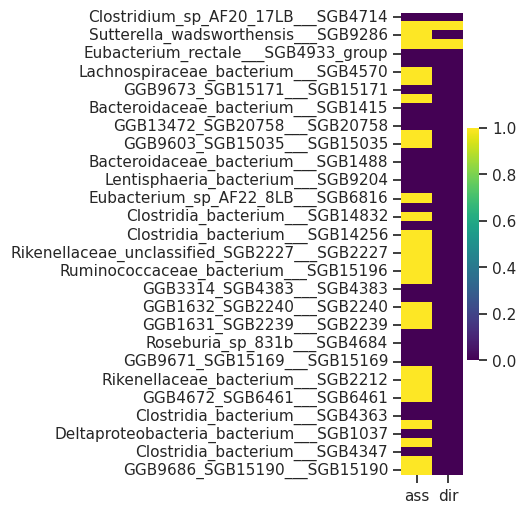

In [86]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.figsize'] = [1,6]
sns.heatmap(for_colors[['ass', 'dir']], cmap='viridis')
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/colors_nw_hg_r.svg')

## Tanzania heatmap

In [532]:
abundances = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_profiles.tsv')
abundances.index = abundances['Unnamed: 0']
abundances = abundances.drop('Unnamed: 0',1)
abundances

/tmp/ipykernel_27292/1478764157.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  abundances = abundances.drop('Unnamed: 0',1)


,MMRS62666492ST-27-0-0,MMRS51737257ST-27-0-0,MMRS38861560ST-27-0-0,MMRS95674036ST-27-0-0,MMRS67096717ST-27-0-0,MMRS84085284ST-27-0-0,MMRS51307502ST-27-0-0,MMRS17963147ST-27-0-0,MMRS39582183ST-27-0-0,MMRS35808664ST-27-0-0,...,SID15785561_SF07,SID19401504_SF05,SID20269046_SF08,SID50492523_SF07,SID10502288_SF08,SID72242320_SF07,SID30920067_SF07,SID11486372_SF08,SID16913125_SF05,SID16853657_SF05
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
k__Bacteria,99.93463,99.18388,100.00000,100.00000,100.00000,100.00000,97.99128,99.92570,93.18519,99.99433,...,100.00000,100.00000,99.20735,100.00000,99.62772,99.57517,99.92819,99.93030,99.53060,100.00000
k__Archaea,0.06537,0.81612,0.00000,0.00000,0.00000,0.00000,2.00872,0.07430,6.81481,0.00567,...,0.00000,0.00000,0.79265,0.00000,0.37228,0.42483,0.07181,0.06970,0.46940,0.00000
k__Bacteria|p__Firmicutes,69.66820,58.11043,69.86201,28.13507,54.76472,48.93404,81.31657,53.89673,70.39620,38.26343,...,62.99205,57.98725,77.37153,56.84940,62.01985,70.64182,57.19654,64.96287,72.69495,56.00511
k__Bacteria|p__Bacteroidetes,28.66924,37.02095,28.10208,66.97080,20.40542,48.32282,10.73218,42.41865,19.37239,51.40790,...,35.22573,38.97574,16.54528,35.27852,27.46251,21.14656,39.11211,20.96019,17.53030,37.48840
k__Bacteria|p__Proteobacteria,0.67858,1.44754,0.66079,2.82776,0.67835,0.02112,3.02764,2.76147,1.31107,9.69329,...,0.49921,0.86482,0.72299,3.39898,3.28930,2.96303,1.12058,11.84127,2.04371,0.62305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidales_unclassified|g__GGB27883|s__GGB27883_SGB40317,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidales_unclassified|g__GGB27883|s__GGB27883_SGB40317|t__SGB40317,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
k__Bacteria|p__Bacteroidetes|c__CFGB570|o__OFGB570|f__FGB570|g__GGB1201,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [533]:
keep = list()
for x in abundances.index.tolist():
    keep.append('t__' in x)
sgb_abundances = abundances.loc[keep]
sgb_abundances.index = [x.split('|')[-2][3:].replace('_',' ') + ' (' + x.split('|')[-1][3:] +')' for x in sgb_abundances.index.tolist()]
sgb_abundances

,MMRS62666492ST-27-0-0,MMRS51737257ST-27-0-0,MMRS38861560ST-27-0-0,MMRS95674036ST-27-0-0,MMRS67096717ST-27-0-0,MMRS84085284ST-27-0-0,MMRS51307502ST-27-0-0,MMRS17963147ST-27-0-0,MMRS39582183ST-27-0-0,MMRS35808664ST-27-0-0,...,SID15785561_SF07,SID19401504_SF05,SID20269046_SF08,SID50492523_SF07,SID10502288_SF08,SID72242320_SF07,SID30920067_SF07,SID11486372_SF08,SID16913125_SF05,SID16853657_SF05
Prevotella copri clade A (SGB1626),11.54777,0.00000,0.00561,0.0,0.00000,9.73808,0.00234,0.0008,5.30270,28.78837,...,0.0,0.0,1.29064,0.00000,0.00000,0.00000,24.37621,0.0,0.00000,0.0
Ruminococcus sp NSJ 71 (SGB4290),6.73408,0.67540,3.45553,0.0,0.00133,0.00000,0.15589,0.0000,0.00000,0.38613,...,0.0,0.0,2.76623,0.00000,0.00000,0.00000,0.00000,0.0,4.52322,0.0
Coprococcus eutactus (SGB5117),5.34157,0.00041,1.53598,0.0,0.00000,0.00000,0.00000,0.0000,0.75849,0.00000,...,0.0,0.0,0.61609,0.00000,0.00000,1.05172,0.94246,0.0,0.00000,0.0
GGB3226 SGB4260 (SGB4260),3.17368,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
Ruminococcaceae unclassified SGB15234 (SGB15234),2.98767,0.00000,0.70183,0.0,0.00000,0.00000,0.92188,0.0000,0.09317,0.00000,...,0.0,0.0,0.16389,0.22321,2.28257,0.88860,0.00000,0.0,2.07058,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GGB28250 SGB40793 (SGB40793),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
GGB27924 SGB40362 (SGB40362),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
Propionibacteriaceae bacterium NML 150081 (SGB15922),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
GGB27883 SGB40317 (SGB40317),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0


In [537]:
tza_df = tza_hg_df.append(tza_rural_df).append(tza_tbdar_df)
tza_df

,SGBs,group,country,population
TZ_81781,168,TZA_HG,TZA,Hunter-Gatherer
TZ_42864,238,TZA_HG,TZA,Hunter-Gatherer
TZ_76219,218,TZA_HG,TZA,Hunter-Gatherer
TZ_70090,223,TZA_HG,TZA,Hunter-Gatherer
TZ_24827,221,TZA_HG,TZA,Hunter-Gatherer
...,...,...,...,...
83997_31,69,NaN,TZA,Urban
84000_31,77,NaN,TZA,Urban
84001_31,86,NaN,TZA,Urban
84002_31,125,NaN,TZA,Urban


In [565]:
tza_abs = sgb_abundances[tza_df.index.tolist()]
tza_abs = tza_abs.drop(tza_abs.loc[tza_abs.sum(axis=1) == 0].index.tolist())
tza_abs = tza_abs.transpose()
tza_abs = tza_abs.drop(tza_abs.loc[tza_abs.sum(axis=1) == 0].index.tolist())
tza_abs = tza_abs.transpose()
tza_abs

,TZ_81781,TZ_42864,TZ_76219,TZ_70090,TZ_24827,TZ_12739,TZ_39371,TZ_83627,TZ_60579,TZ_86771,...,83984_31,83985_31,83987_31,83991_31,83994_31,83997_31,84000_31,84001_31,84002_31,84004_31
Prevotella copri clade A (SGB1626),21.97253,2.09350,1.19055,0.43051,0.55323,1.23682,0.23952,0.41161,0.28592,1.15116,...,0.00011,0.20069,0.51516,0.00782,0.0000,0.01010,0.0,0.0000,0.00000,0.05297
Ruminococcus sp NSJ 71 (SGB4290),0.05329,0.41731,0.00000,0.01385,0.55393,0.40421,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00052
Coprococcus eutactus (SGB5117),0.00000,0.00000,0.00000,0.46499,0.00000,0.19405,0.00000,0.00677,0.00197,0.00000,...,0.00000,0.36817,0.00000,0.00000,0.3024,0.34068,0.0,0.0000,1.00590,0.00000
GGB3226 SGB4260 (SGB4260),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00000
Ruminococcaceae unclassified SGB15234 (SGB15234),0.00000,0.00578,0.13178,0.00000,0.00000,0.00000,0.84834,0.05657,0.13881,0.00000,...,0.00167,0.00513,0.00000,0.10056,0.0000,0.00000,0.0,0.0968,0.07346,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Enterobacteriaceae bacterium BIT l23 (SGB58219),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00000
Cetobacterium sp ZOR0034 (SGB29022),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00000
Cetobacterium sp 8H (SGB77487),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00000
Clostridium collagenovorans (SGB7886),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00000


In [574]:
tza_abs.astype(bool).astype(int).transpose().sum()

Prevotella copri clade A (SGB1626)                  274
Ruminococcus sp NSJ 71 (SGB4290)                    142
Coprococcus eutactus (SGB5117)                      160
GGB3226 SGB4260 (SGB4260)                            10
Ruminococcaceae unclassified SGB15234 (SGB15234)    226
                                                   ... 
Enterobacteriaceae bacterium BIT l23 (SGB58219)       1
Cetobacterium sp ZOR0034 (SGB29022)                   1
Cetobacterium sp 8H (SGB77487)                        1
Clostridium collagenovorans (SGB7886)                 1
Campylobacter sp RM12175 (SGB19458)                   1
Length: 2316, dtype: int64

In [599]:
above_20 = (tza_abs.astype(bool).astype(int).transpose().sum() / tza_abs.astype(bool).transpose().astype(int).count()) > 0.6
tza_abs_20 = tza_abs.loc[above_20.values]
tza_abs_20

,TZ_81781,TZ_42864,TZ_76219,TZ_70090,TZ_24827,TZ_12739,TZ_39371,TZ_83627,TZ_60579,TZ_86771,...,83984_31,83985_31,83987_31,83991_31,83994_31,83997_31,84000_31,84001_31,84002_31,84004_31
Prevotella copri clade A (SGB1626),21.97253,2.09350,1.19055,0.43051,0.55323,1.23682,0.23952,0.41161,0.28592,1.15116,...,0.00011,0.20069,0.51516,0.00782,0.00000,0.01010,0.00000,0.00000,0.00000,0.05297
Ruminococcaceae unclassified SGB15234 (SGB15234),0.00000,0.00578,0.13178,0.00000,0.00000,0.00000,0.84834,0.05657,0.13881,0.00000,...,0.00167,0.00513,0.00000,0.10056,0.00000,0.00000,0.00000,0.09680,0.07346,0.00000
Faecalibacterium prausnitzii (SGB15332_group),2.68711,1.45004,0.84650,0.17122,1.64457,0.44223,0.64253,0.06504,0.03731,0.50036,...,0.00000,0.01573,0.20412,0.00000,0.10208,0.05802,0.10166,0.03898,0.01795,0.04950
Oscillibacter sp ER4 (SGB15254),0.13256,0.31546,0.51404,0.23931,0.18517,0.79293,0.08075,2.35801,0.89919,0.39244,...,0.00000,0.00595,0.00966,0.00500,0.00479,0.00498,0.08730,0.06029,0.02271,0.00000
Lachnospira eligens (SGB5082_group),0.10746,0.31183,0.03340,0.00000,0.29806,0.02011,0.00000,0.00000,0.00000,0.16267,...,0.00000,0.03671,0.00000,0.00118,0.09517,0.12991,0.00000,0.00000,0.08004,0.01903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Klebsiella pneumoniae (SGB10115),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.34372,0.00102,0.04581,0.02569,1.18464,1.15632,0.04450,0.98053,1.92900,0.26256
Lachnospiraceae bacterium (SGB4808),0.01986,0.00932,0.05512,0.00000,0.06603,0.05531,0.94772,0.00727,0.18201,0.18920,...,0.00000,0.00000,0.07870,0.00000,0.00000,0.23776,0.12894,0.06242,0.22113,0.00000
Clostridium sp NSJ 42 (SGB6174_group),0.24753,0.00000,0.00000,1.89990,0.04329,0.00000,0.01053,2.73751,2.67452,0.06406,...,0.01181,0.00000,0.00715,0.81987,0.16787,0.00000,0.03924,0.00000,0.14676,0.04653
Blautia sp AF19 10LB (SGB4810),0.05035,0.00000,0.00000,0.00000,0.10288,0.06764,0.11282,0.00000,0.00000,0.00000,...,0.28440,0.29775,0.11674,0.80400,16.36294,0.03597,0.00000,0.00000,0.05446,0.01675


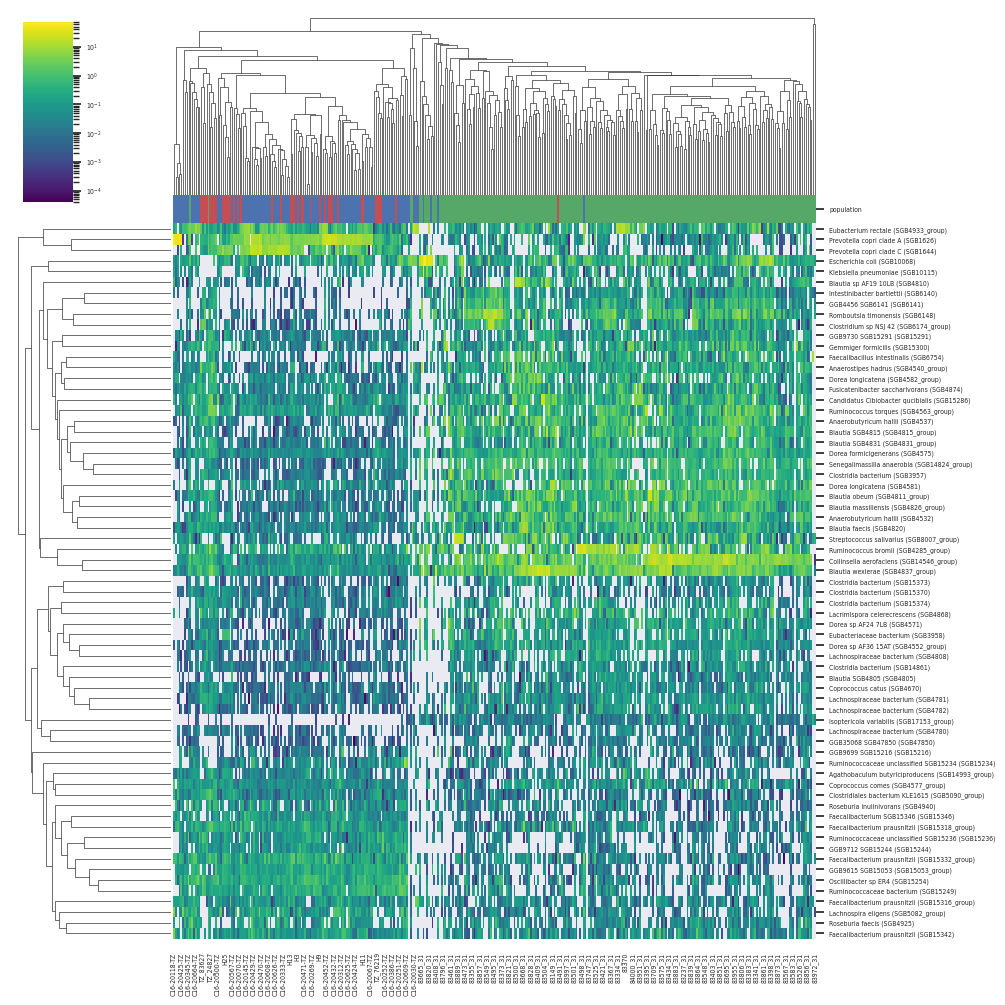

In [623]:
sns.set(font_scale=0.4)
lut = dict(zip(tza_df.population.unique(), "rbg"))
row_colors = tza_df.population.map(lut)
sns.clustermap(tza_abs_20, norm=LogNorm(), col_cluster=True, col_colors=row_colors, cmap='viridis', metric='braycurtis')

In [621]:
tza_abs.loc['Clostridium phoceensis (SGB15154)'].astype(bool).astype(int).transpose().sum()

26

## Doing some filtering

In [624]:
tza_abs

,TZ_81781,TZ_42864,TZ_76219,TZ_70090,TZ_24827,TZ_12739,TZ_39371,TZ_83627,TZ_60579,TZ_86771,...,83984_31,83985_31,83987_31,83991_31,83994_31,83997_31,84000_31,84001_31,84002_31,84004_31
Prevotella copri clade A (SGB1626),21.97253,2.09350,1.19055,0.43051,0.55323,1.23682,0.23952,0.41161,0.28592,1.15116,...,0.00011,0.20069,0.51516,0.00782,0.0000,0.01010,0.0,0.0000,0.00000,0.05297
Ruminococcus sp NSJ 71 (SGB4290),0.05329,0.41731,0.00000,0.01385,0.55393,0.40421,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00052
Coprococcus eutactus (SGB5117),0.00000,0.00000,0.00000,0.46499,0.00000,0.19405,0.00000,0.00677,0.00197,0.00000,...,0.00000,0.36817,0.00000,0.00000,0.3024,0.34068,0.0,0.0000,1.00590,0.00000
GGB3226 SGB4260 (SGB4260),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00000
Ruminococcaceae unclassified SGB15234 (SGB15234),0.00000,0.00578,0.13178,0.00000,0.00000,0.00000,0.84834,0.05657,0.13881,0.00000,...,0.00167,0.00513,0.00000,0.10056,0.0000,0.00000,0.0,0.0968,0.07346,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Enterobacteriaceae bacterium BIT l23 (SGB58219),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00000
Cetobacterium sp ZOR0034 (SGB29022),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00000
Cetobacterium sp 8H (SGB77487),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00000
Clostridium collagenovorans (SGB7886),0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0,0.0000,0.00000,0.00000


In [626]:
thg = tza_hg_df.index.tolist()
tr = tza_rural_df.index.tolist()
tu = tza_tbdar_df.index.tolist()

In [694]:
pvalues = dict()
for species in tza_abs.index.tolist():
    s_hg = tza_abs.loc[species, thg]
    s_r = tza_abs.loc[species, tr]
    s_u = tza_abs.loc[species, tu]
    if set(s_hg.values.tolist()) != set(s_r.values.tolist()):
        _, phgrg = mannwhitneyu(s_hg, s_r, alternative='greater')
        _, phgrl = mannwhitneyu(s_hg, s_r, alternative='less')
    else:
        phgr = 1
    if set(s_hg.values.tolist()) != set(s_u.values.tolist()):
        _, phgug = mannwhitneyu(s_hg, s_u, alternative='greater')
        _, phgul = mannwhitneyu(s_hg, s_u, alternative='less')
    else:
        phu = 1
    if set(s_r.values.tolist()) != set(s_u.values.tolist()):
        _, prug = mannwhitneyu(s_r, s_u, alternative='greater')
        _, prul = mannwhitneyu(s_r, s_u, alternative='less')
    else:
        pru = 1
    
    pvalues[species] = [phgrg, phgug, prug, phgrl, phgul, prul]

In [695]:
qvalues = dict()
_, qhgrg = fdrcorrection([pvalues[species][0] for species in pvalues])
_, qhgug = fdrcorrection([pvalues[species][1] for species in pvalues])
_, qrug = fdrcorrection([pvalues[species][2] for species in pvalues])
_, qhgrl = fdrcorrection([pvalues[species][3] for species in pvalues])
_, qhgul = fdrcorrection([pvalues[species][4] for species in pvalues])
_, qrul = fdrcorrection([pvalues[species][5] for species in pvalues])

In [696]:
for k, species in enumerate(list(pvalues.keys())):
    qvalues[species] = [qhgrg[k], qhgug[k], qrug[k], qhgrl[k], qhgul[k], qrul[k]]

In [697]:
species2showhg = dict()
species2showr = dict()
species2showu = dict()
filterq=0.05
for s in qvalues:
    if qvalues[s][0] < filterq and qvalues[s][1] < filterq:
        species2showhg[s] = statistics.mean([qvalues[s][0], qvalues[s][1]])
    if qvalues[s][2] < filterq and qvalues[s][3] < filterq:
        species2showr[s] = statistics.mean([qvalues[s][0], qvalues[s][2]])
    if qvalues[s][4] < filterq and qvalues[s][5] < filterq:
        species2showu[s] = statistics.mean([qvalues[s][1], qvalues[s][2]])

In [705]:
tops = 10
species2show = [k for k, v in sorted(species2showhg.items(), key=lambda item: item[1])][0:tops] + [k for k, v in sorted(species2showr.items(), key=lambda item: item[1])][0:tops]+ [k for k, v in sorted(species2showu.items(), key=lambda item: item[1])][0:tops]

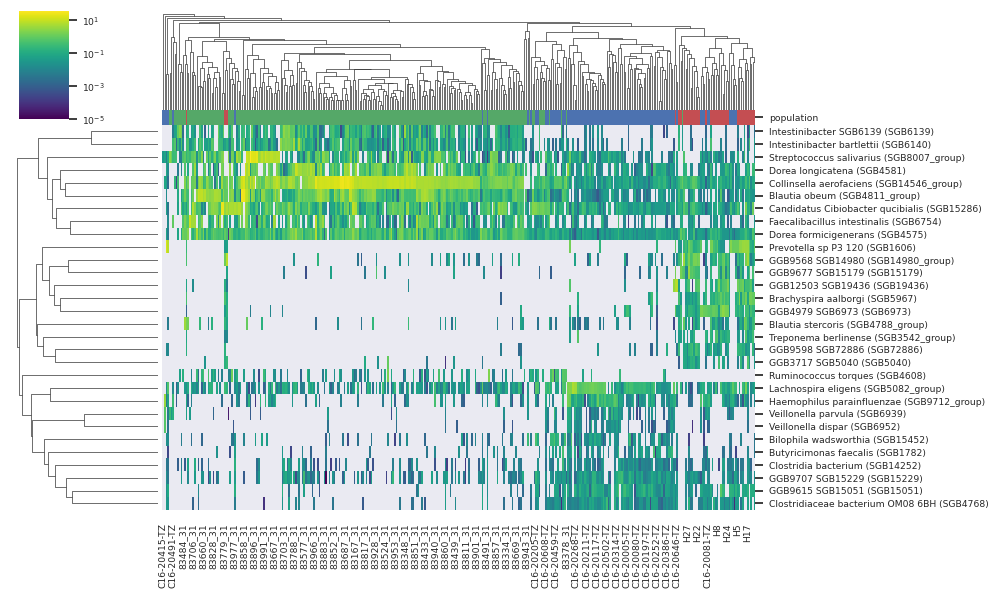

In [712]:
sns.set(font_scale=0.6)
lut = dict(zip(tza_df.population.unique(), "rbg"))
row_colors = tza_df.population.map(lut)
filt_abs = tza_abs.loc[species2show].copy()
filt_abs = filt_abs.drop(filt_abs.loc[filt_abs.sum(axis=1) == 0].index.tolist())
filt_abs = filt_abs.transpose()
filt_abs = filt_abs.drop(filt_abs.loc[filt_abs.sum(axis=1) == 0].index.tolist())
filt_abs = filt_abs.transpose()
sns.clustermap(filt_abs, norm=LogNorm(), col_cluster=True, figsize=(10, 6), col_colors=row_colors, cmap='viridis', metric='braycurtis')
plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/tza_hg_r_u_heatmap.svg')